In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
path = r"D:\Vehicle_Mileage_Project\data\raw\ML Dataset.xlsx"

df = pd.read_excel(path)

In [2]:
print("Shape Before Cleaning :", df.shape)

Shape Before Cleaning : (64849, 27)


In [3]:
df = df.drop_duplicates()

In [4]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [5]:
print(df.shape)

(64303, 27)


In [6]:
df.isnull().sum()

Vehicle_ID                    1
Manufacturer                  2
Model                         1
Vehicle_Age                 293
Engine_CC                     1
Horsepower                    4
Vehicle_Weight                2
Transmission                  3
Fuel_Type                     1
Ethanol_Blend                 1
Fuel_Price                    1
Trip_Distance_km              3
Average_Speed                 3
Engine_RPM                    5
Tire_Pressure_PSI             2
Maintenance_Status            2
Road_Type                     2
Traffic_Level                 0
Temperature                   2
Humidity                      3
Weather                       4
AC_Usage                      1
Driving_Style                 1
Passengers                    4
CO2_Emission_g_km             1
Fuel_Consumption_L_100km      1
Mileage_km_per_L            330
dtype: int64

In [7]:
df = df.dropna(subset=["Mileage_km_per_L"])

In [8]:
df["Mileage_km_per_L"].isnull().sum()

np.int64(0)

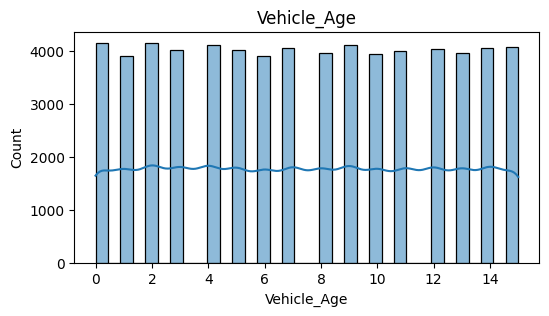

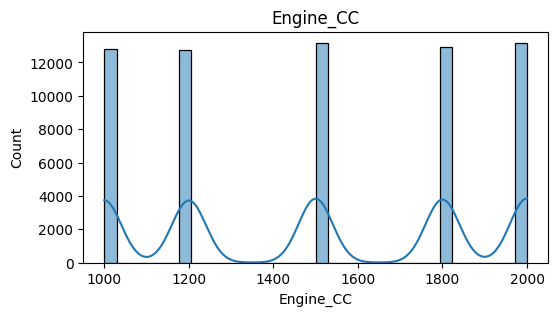

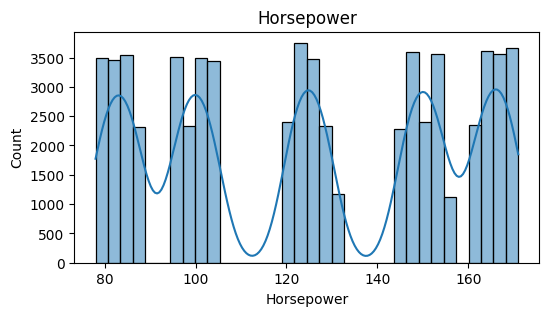

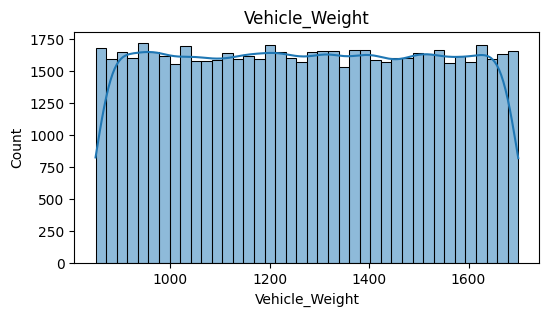

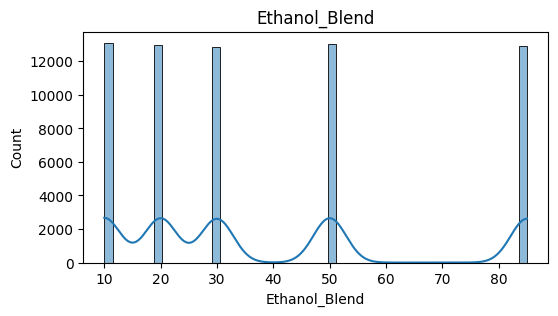

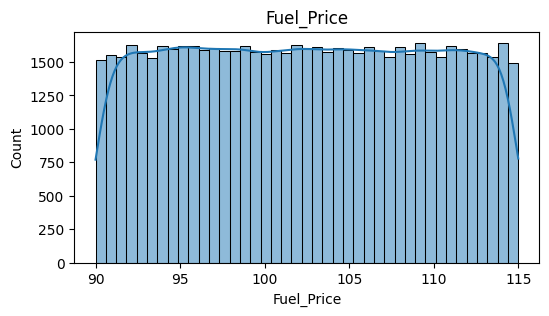

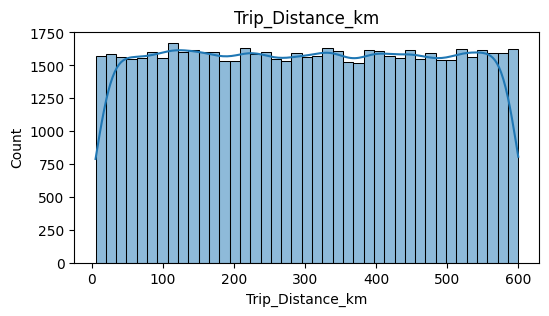

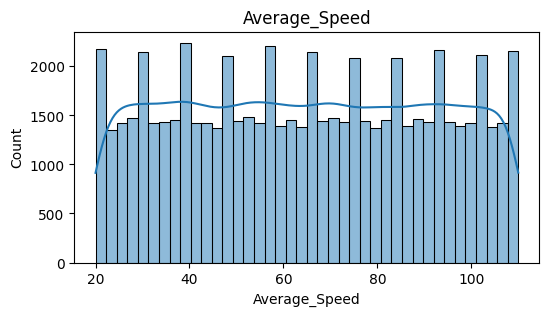

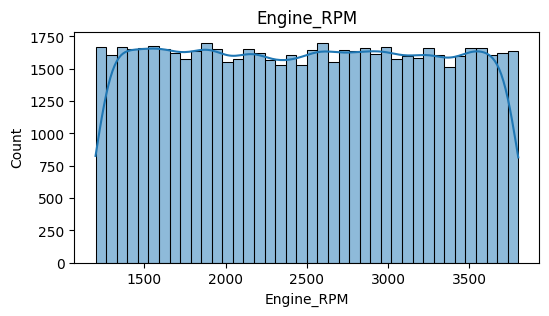

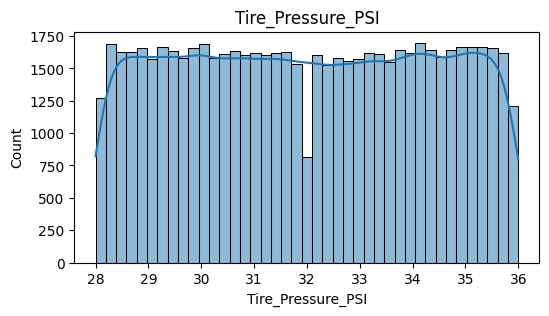

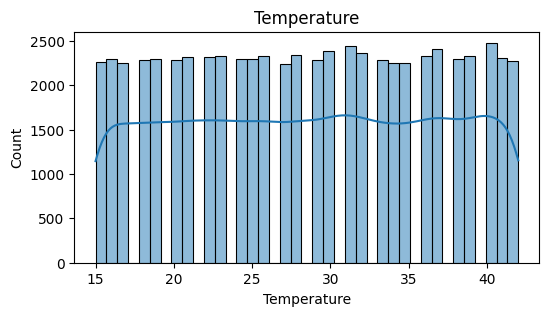

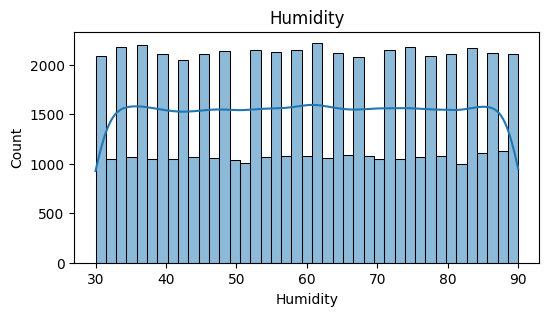

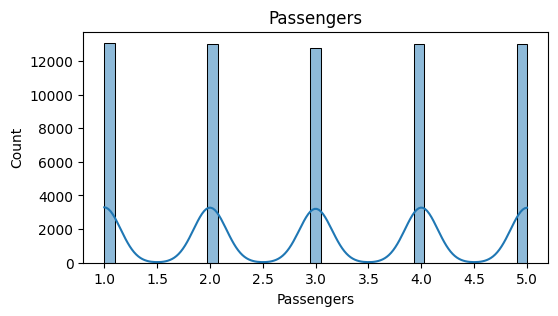

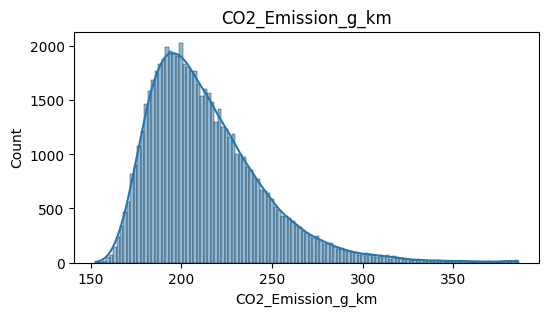

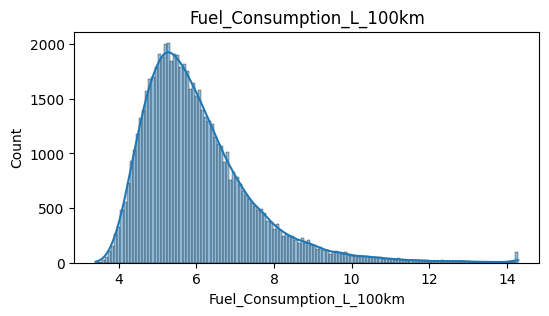

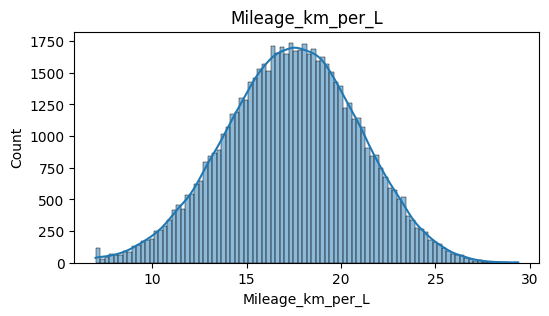

In [11]:
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [12]:
df[numerical_columns].skew()

Vehicle_Age                 0.004745
Engine_CC                  -0.014867
Horsepower                 -0.029045
Vehicle_Weight              0.002451
Ethanol_Blend               0.715907
Fuel_Price                  0.002998
Trip_Distance_km            0.002619
Average_Speed               0.007320
Engine_RPM                  0.006179
Tire_Pressure_PSI           0.001076
Temperature                -0.010474
Humidity                   -0.003497
Passengers                  0.001694
CO2_Emission_g_km           1.298080
Fuel_Consumption_L_100km    1.605762
Mileage_km_per_L           -0.095848
dtype: float64

In [13]:
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:

    # Skip target column
    if col == "Mileage_km_per_L":
        continue

    skew = df[col].skew()

    if abs(skew) <= 0.5:
        df[col] = df[col].fillna(df[col].mean())
        print(f"{col} --> Mean (Skewness = {skew:.3f})")

    else:
        df[col] = df[col].fillna(df[col].median())
        print(f"{col} --> Median (Skewness = {skew:.3f})")

Vehicle_Age --> Mean (Skewness = 0.005)
Engine_CC --> Mean (Skewness = -0.015)
Horsepower --> Mean (Skewness = -0.029)
Vehicle_Weight --> Mean (Skewness = 0.002)
Ethanol_Blend --> Median (Skewness = 0.716)
Fuel_Price --> Mean (Skewness = 0.003)
Trip_Distance_km --> Mean (Skewness = 0.003)
Average_Speed --> Mean (Skewness = 0.007)
Engine_RPM --> Mean (Skewness = 0.006)
Tire_Pressure_PSI --> Mean (Skewness = 0.001)
Temperature --> Mean (Skewness = -0.010)
Humidity --> Mean (Skewness = -0.003)
Passengers --> Mean (Skewness = 0.002)
CO2_Emission_g_km --> Median (Skewness = 1.298)
Fuel_Consumption_L_100km --> Median (Skewness = 1.606)


In [14]:
categorical_columns = df.select_dtypes(include=["object", "string"]).columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [15]:
df.isnull().sum()

Vehicle_ID                    0
Manufacturer                  0
Model                         0
Vehicle_Age                   0
Engine_CC                     0
Horsepower                    0
Vehicle_Weight                0
Transmission                  0
Fuel_Type                     0
Ethanol_Blend                 0
Fuel_Price                    0
Trip_Distance_km              0
Average_Speed                 0
Engine_RPM                    0
Tire_Pressure_PSI             0
Maintenance_Status            0
Road_Type                     0
Traffic_Level                 0
Temperature                   0
Humidity                      0
Weather                       0
AC_Usage                      0
Driving_Style                 0
Passengers                    0
CO2_Emission_g_km             0
Fuel_Consumption_L_100km      0
Mileage_km_per_L            334
dtype: int64

In [16]:
df.isnull().sum()

Vehicle_ID                    0
Manufacturer                  0
Model                         0
Vehicle_Age                   0
Engine_CC                     0
Horsepower                    0
Vehicle_Weight                0
Transmission                  0
Fuel_Type                     0
Ethanol_Blend                 0
Fuel_Price                    0
Trip_Distance_km              0
Average_Speed                 0
Engine_RPM                    0
Tire_Pressure_PSI             0
Maintenance_Status            0
Road_Type                     0
Traffic_Level                 0
Temperature                   0
Humidity                      0
Weather                       0
AC_Usage                      0
Driving_Style                 0
Passengers                    0
CO2_Emission_g_km             0
Fuel_Consumption_L_100km      0
Mileage_km_per_L            334
dtype: int64

In [17]:
print("Shape After Cleaning :", df.shape)

Shape After Cleaning : (64849, 27)


In [18]:
df.dtypes

Vehicle_ID                      str
Manufacturer                    str
Model                           str
Vehicle_Age                 float64
Engine_CC                   float64
Horsepower                  float64
Vehicle_Weight              float64
Transmission                    str
Fuel_Type                       str
Ethanol_Blend               float64
Fuel_Price                  float64
Trip_Distance_km            float64
Average_Speed               float64
Engine_RPM                  float64
Tire_Pressure_PSI           float64
Maintenance_Status              str
Road_Type                       str
Traffic_Level                   str
Temperature                 float64
Humidity                    float64
Weather                         str
AC_Usage                        str
Driving_Style                   str
Passengers                  float64
CO2_Emission_g_km           float64
Fuel_Consumption_L_100km    float64
Mileage_km_per_L            float64
dtype: object

In [19]:
df.duplicated().sum()

np.int64(546)

In [20]:
df.duplicated().sum()

np.int64(546)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64849 entries, 0 to 64848
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Vehicle_ID                64849 non-null  str    
 1   Manufacturer              64849 non-null  str    
 2   Model                     64849 non-null  str    
 3   Vehicle_Age               64849 non-null  float64
 4   Engine_CC                 64849 non-null  float64
 5   Horsepower                64849 non-null  float64
 6   Vehicle_Weight            64849 non-null  float64
 7   Transmission              64849 non-null  str    
 8   Fuel_Type                 64849 non-null  str    
 9   Ethanol_Blend             64849 non-null  float64
 10  Fuel_Price                64849 non-null  float64
 11  Trip_Distance_km          64849 non-null  float64
 12  Average_Speed             64849 non-null  float64
 13  Engine_RPM                64849 non-null  float64
 14  Tire_Pressure_PSI

In [22]:
cleaning_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Data Type": df.dtypes
})

cleaning_summary

,Missing Values,Data Type
Vehicle_ID,0,str
Manufacturer,0,str
Model,0,str
Vehicle_Age,0,float64
Engine_CC,0,float64
Horsepower,0,float64
Vehicle_Weight,0,float64
Transmission,0,str
Fuel_Type,0,str
Ethanol_Blend,0,float64


In [23]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)
print("Duplicates:", df.duplicated().sum())

Before: (64849, 27)
After: (64303, 27)
Duplicates: 0


In [24]:
df = df.drop_duplicates()

print(df.duplicated().sum())

0


In [25]:
print(df.shape)

print(df.duplicated().sum())

(64303, 27)
0


In [26]:
cleaning_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

cleaning_report

,Data Type,Missing Values,Unique Values
Vehicle_ID,str,0,64302
Manufacturer,str,0,5
Model,str,0,8
Vehicle_Age,float64,0,17
Engine_CC,float64,0,6
Horsepower,float64,0,56
Vehicle_Weight,float64,0,852
Transmission,str,0,2
Fuel_Type,str,0,1
Ethanol_Blend,float64,0,5


In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Vehicle_Age,64303.0,7.483402,4.610689,0.0,3.00,7.485315,11.00,15.00
Engine_CC,64303.0,1503.788375,368.692897,1000.0,1200.00,1500.000000,1800.00,2000.00
Horsepower,64303.0,125.107016,30.808953,78.0,97.00,125.000000,153.00,171.00
Vehicle_Weight,64303.0,1274.405827,245.841700,850.0,1061.00,1274.000000,1488.00,1700.00
Ethanol_Blend,64303.0,38.921512,26.521361,10.0,20.00,30.000000,50.00,85.00
Fuel_Price,64303.0,102.497633,7.193518,90.0,96.27,102.490000,108.73,115.00
Trip_Distance_km,64303.0,302.732433,171.989959,5.0,153.30,302.700000,451.60,600.00
Average_Speed,64303.0,64.883795,26.253822,20.0,42.00,65.000000,88.00,110.00
Engine_RPM,64303.0,2495.773083,752.768132,1200.0,1841.00,2500.000000,3147.00,3800.00
Tire_Pressure_PSI,64303.0,31.997000,2.323723,28.0,30.00,32.000000,34.00,36.00


In [28]:
df.to_csv(
    r"D:\Vehicle_Mileage_Project\data\processed\cleaned_dataset.csv",
    index=False
)

In [29]:
df.to_excel(
    r"D:\Vehicle_Mileage_Project\data\processed\cleaned_dataset.xlsx",
    index=False
)

In [32]:
cleaned_df = pd.read_csv(
    r"D:\Vehicle_Mileage_Project\data\processed\cleaned_dataset.csv"
)

cleaned_df.head()

,Vehicle_ID,Manufacturer,Model,Vehicle_Age,Engine_CC,Horsepower,Vehicle_Weight,Transmission,Fuel_Type,Ethanol_Blend,...,Traffic_Level,Temperature,Humidity,Weather,AC_Usage,Driving_Style,Passengers,CO2_Emission_g_km,Fuel_Consumption_L_100km,Mileage_km_per_L
0,V014767,Tata,Nexon,13.0,1000.0,82.0,1307.0,Automatic,Petrol,20.0,...,High,27.0,61.0,Fog,No,Normal,1.0,192.1,5.00,20.02
1,V020736,Toyota,Glanza,8.0,1200.0,98.0,1493.0,Automatic,Petrol,20.0,...,High,30.0,48.0,Fog,Yes,Smooth,3.0,189.2,5.12,19.52
2,V041583,Maruti,Baleno,9.0,1200.0,103.0,1262.0,Automatic,Petrol,20.0,...,Medium,34.0,44.0,Fog,Yes,Aggressive,1.0,197.3,5.55,18.01
3,V042258,Honda,City,14.0,1200.0,95.0,1001.0,Manual,Petrol,10.0,...,High,15.0,53.0,Rain,Yes,Normal,1.0,185.8,5.23,19.12
4,V029600,Tata,Altroz,15.0,1800.0,148.0,1604.0,Manual,Petrol,10.0,...,Medium,24.0,65.0,Fog,Yes,Smooth,1.0,197.7,5.90,16.96


In [33]:
cleaned_df.shape

(64303, 27)

In [34]:
cleaned_df.isnull().sum()

Vehicle_ID                    0
Manufacturer                  0
Model                         0
Vehicle_Age                   0
Engine_CC                     0
Horsepower                    0
Vehicle_Weight                0
Transmission                  0
Fuel_Type                     0
Ethanol_Blend                 0
Fuel_Price                    0
Trip_Distance_km              0
Average_Speed                 0
Engine_RPM                    0
Tire_Pressure_PSI             0
Maintenance_Status            0
Road_Type                     0
Traffic_Level                 0
Temperature                   0
Humidity                      0
Weather                       0
AC_Usage                      0
Driving_Style                 0
Passengers                    0
CO2_Emission_g_km             0
Fuel_Consumption_L_100km      0
Mileage_km_per_L            330
dtype: int64

In [35]:
missing = cleaned_df["Mileage_km_per_L"].isnull().sum()

percentage = (missing / len(cleaned_df)) * 100

print("Missing Values :", missing)
print("Percentage :", round(percentage,2),"%")

Missing Values : 330
Percentage : 0.51 %


In [36]:
print("Before:", cleaned_df.shape)

cleaned_df = cleaned_df.dropna(subset=["Mileage_km_per_L"])

print("After:", cleaned_df.shape)

Before: (64303, 27)
After: (63973, 27)


In [37]:
cleaned_df["Mileage_km_per_L"].isnull().sum()

np.int64(0)

In [38]:
cleaned_df.to_csv(
    r"D:\Vehicle_Mileage_Project\data\processed\cleaned_dataset.csv",
    index=False
)

print("Target column cleaned successfully.")

Target column cleaned successfully.
